## **BackGround**
- AI Hub의 국내 여행로그 데이터 (수도권/동부권/서부권)을 여행 계획 생성 모델에 사용하기 위한 데이터 탐색용 노트북입니다. 

## **0. Import & Setting**

In [70]:
import os 
import unicodedata
import pandas as pd 
from pathlib import Path
from IPython.display import display, Markdown
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"  # 맑은 고딕
plt.rcParams["axes.unicode_minus"] = False     # 마이너스 깨짐 방지

In [71]:
ROOT_PATH = Path.cwd().parent
DATA_PATH = ROOT_PATH/"data"
REPORTS_PATH = ROOT_PATH/"reports"
FIGURES_PATH = REPORTS_PATH/"figures"
CENTRAL_PATH = DATA_PATH/"raw/central/145.국내 여행로그 데이터_수도권_2차년도/3.개방데이터/1.데이터/Training/02.라벨링데이터/TL_CSV/"
EAST_PATH = DATA_PATH/"raw/east/146.국내 여행로그 데이터_동부권_2차년도/3.개방데이터/1.데이터/Training/02.라벨링데이터/TL_CSV/"
WEST_PATH = DATA_PATH/"raw/west/147.국내 여행로그 데이터_서부권_2차년도/3.개방데이터/1.데이터/Training/02.라벨링데이터/TL_CSV/"

FIGURES_PATH.mkdir(parents=True, exist_ok=True)

assert all(path.exists() and len(list(path.iterdir()))==14 \
    for path in [CENTRAL_PATH,EAST_PATH,WEST_PATH]),\
    "경로 오류 또는 csv 파일 불일치"


In [72]:
'''
central : E 
east : F
west : G 
'''

for file in list(WEST_PATH.iterdir()):
    print(file.name)

tc_codea_코드A.csv
tc_codeb_코드B.csv
tc_sgg_시군구코드.csv
tn_activity_consume_his_활동소비내역_G.csv
tn_activity_his_활동내역_G.csv
tn_adv_consume_his_사전소비내역_G.csv
tn_companion_info_동반자정보_G.csv
tn_lodge_consume_his_숙박소비내역_G.csv
tn_move_his_이동내역_G.csv
tn_mvmn_consume_his_이동수단소비내역_G.csv
tn_tour_photo_관광사진_G.csv
tn_traveller_master_여행객_Master_G.csv
tn_travel_여행_G.csv
tn_visit_area_info_방문지정보_G.csv


## **1. Analytics & Visualization**

In [73]:
# 공용 함수

'''
make_name_efg
df_name을 efg별 csv 파일 경로로 확장시키는 함수
'''
def make_name_efg(df_name: str):
    df_name = unicodedata.normalize("NFC", df_name)
    e_path = CENTRAL_PATH / (df_name + "_E.csv")
    f_path = EAST_PATH / (df_name + "_F.csv")
    g_path = WEST_PATH / (df_name + "_G.csv")

    return e_path, f_path, g_path


'''
print_col_efg
df_name을 가지는 df를 e,f,g 출력하는 함수

df_name : csv 확장자 제외한 파일 이름
'''
def print_col_efg(df_name: str):
    e_path, f_path, g_path = make_name_efg(df_name)

    e_df = pd.read_csv(e_path)
    f_df = pd.read_csv(f_path)
    g_df = pd.read_csv(g_path)

    if e_df.columns.equals(f_df.columns) and f_df.columns.equals(g_df.columns):
        display(Markdown(f"### ===EFG 공통 : {df_name}==="))
        print(e_df.columns)
    else:
        display(Markdown(f"### ==={df_name}==="))
        common_cols = set(e_df.columns) & set(f_df.columns) & set(g_df.columns)
        all_cols = set(e_df.columns) | set(f_df.columns) | set(g_df.columns)
        print(f"교집합 컬럼 : {common_cols}")
        print(f"차집합 컬럼 : {all_cols - common_cols}")


'''
concat_efg
컬럼이 모두 같은 3개의 EFG 파일 통합시키는 메서드

df_name : csv 확장자 제외한 파일 이름
'''
def concat_efg(df_name: str):
    e_path, f_path, g_path = make_name_efg(df_name)

    e_df = pd.read_csv(e_path)
    f_df = pd.read_csv(f_path)
    g_df = pd.read_csv(g_path)

    total_df = pd.concat([e_df, f_df, g_df], axis=0, ignore_index=True)

    return total_df


'''
unique_codes
컬럼을 df에서 가져와서 unique한 값들을 정렬해서 반환하는 함수
'''
def unique_codes(columns, df):
    values = pd.concat([df[col] for col in columns], ignore_index=True)
    return sorted(values.dropna().astype(int).unique().tolist())


'''
assert_same_unique_values
세 권역 파일에서 특정 컬럼의 고유값이 모두 같은지 확인하는 함수
'''
def assert_same_unique_values(paths, column: str, message: str):
    unique_values = [set(pd.read_csv(path)[column].dropna().unique()) for path in paths]
    first_values = unique_values[0]

    assert all(values == first_values for values in unique_values[1:]), message

    return first_values


'''
save_figure
matplotlib figure를 공통 figure 폴더에 저장하는 함수
'''
def save_figure(fig, filename: str) -> Path:
    output_path = FIGURES_PATH / filename
    fig.savefig(output_path, bbox_inches="tight", dpi=150)
    return output_path


### (1) CODE A, B, SGG 코드 
- CODE A, B는 여행 특성, 방문 목적 등을 코드로 분류한 표기표로 W,E,C 모두 동일 -> 병합할 필요 없음
- SGG CODE 또한 동일 -> 병합 필요 없음 
- 그 외 여행 데이터 csv는 모두 TRAVEL ID를 기준으로 구분됨 

In [74]:
## 코드 A 데이터를 병합할 필요가 있을지 확인
c_codea_path = CENTRAL_PATH / "tc_codea_코드A.csv"
w_codea_path = WEST_PATH / "tc_codea_코드A.csv"
e_codea_path = EAST_PATH / "tc_codea_코드A.csv"

c_codea_df = pd.read_csv(c_codea_path)
w_codea_df = pd.read_csv(w_codea_path)
e_codea_df = pd.read_csv(e_codea_path)

## cd_nm이 모두 동일하다면 굳이 병합할 필요 없음
codea_cd_nm = assert_same_unique_values(
    [c_codea_path, w_codea_path, e_codea_path],
    "cd_nm",
    "cd_nm 동일하지 않음",
)

print(codea_cd_nm)


{'취식 지출 여부', '여행권역', '여행동기', '재방문 의향 점수', '여행빈도_기간', '재방문여부', '직업', '최종학력이수여부', '추천의향 점수', '직업기타', '입장료구분', '여행동반자관계', '동반자연령대', '혼인상태', '결제 방식', '방문지유형코드', '방문선택이유', '방문활동', '여행종류', '최종학력', '동반자동반상황', '메타데이터 진행상태', '전반적 만족도 점수', '여행상태', '주요 이동수단', '소득', '여행스타일', '성별', '미션', '숙소유형'}


In [75]:
c_codea_df.head()

,idx,cd_a,cd_nm,cd_memo,cd_memo2,del_flag,order_num,perm_write,perm_edit,perm_delete,ins_dt,edit_dt
0,5,STA,여행상태,NaN,NaN,N,999,N,N,N,2022-07-05 10:33:02,NaN
1,6,VIS,방문지유형코드,NaN,NaN,N,999,N,N,N,2022-07-05 10:45:53,NaN
2,7,MOV,주요 이동수단,NaN,NaN,N,999,N,N,N,2022-07-05 10:48:39,NaN
3,8,REV,재방문여부,NaN,NaN,N,999,N,N,N,2022-07-05 11:27:33,NaN
4,9,REN,방문선택이유,NaN,NaN,N,999,N,N,N,2022-07-05 11:28:18,NaN


In [76]:
c_codea_df[c_codea_df["cd_a"]=="MIS"]

,idx,cd_a,cd_nm,cd_memo,cd_memo2,del_flag,order_num,perm_write,perm_edit,perm_delete,ins_dt,edit_dt
14,19,MIS,미션,"여행테이블 여행목적, 여행미션에서 사용",NaN,N,999,N,N,N,2022-07-27 16:26:46,NaN


In [77]:
## 코드 B 데이터를 병합할 필요가 있을지 확인
c_codeb_path = CENTRAL_PATH / "tc_codeb_코드B.csv"
w_codeb_path = WEST_PATH / "tc_codeb_코드B.csv"
e_codeb_path = EAST_PATH / "tc_codeb_코드B.csv"

c_codeb_df = pd.read_csv(c_codeb_path)
w_codeb_df = pd.read_csv(w_codeb_path)
e_codeb_df = pd.read_csv(e_codeb_path)

## cd_nm이 모두 동일하다면 굳이 병합할 필요 없음
codeb_cd_nm = assert_same_unique_values(
    [c_codeb_path, w_codeb_path, e_codeb_path],
    "cd_nm",
    "cd_nm 동일하지 않음",
)

print(codeb_cd_nm)


{'여행 중', '시외/고속버스', '시내/마을버스', '지하철', '30대', '불만족', '월평균 100만원 ~ 200만원 미만', '지인의 추천이 있어서', '재학', '그렇다', '일상적인 환경 및 역할에서의 탈출, 지루함 탈피', '레저/스포츠 관련 시설(스키, 카트, 수상레저)', '기능원 및 관련 기능 종사자', '모텔/여관', '동료', '도시 선호 약간선호', '여행 후(기록전)', '호캉스 여행', '항공기', '충남', '이 방문지에서 구매', '조부모', '지역 축제/행사', '대학(4년제 미만)', '졸업', '민박', '친인척', '테스트 사진 업로드', '장치․기계 조작 및 조립 종사자', '기타 활동', '없음', '도보', '매우 불만족', '경남', '중립', '산책로, 둘레길 등', '판매 종사자', '전업주부', '연인', '특별한 목적(칠순여행, 신혼여행, 수학여행, 인센티브여행)', 'KTX/SRT(고속열차)', '카드 일시불', '중퇴', '체험 활동 관광지', '테마시설(놀이공원, 워터파크)', '진정한 자아 찾기 또는 자신을 되돌아볼 기회 찾기', '소득없음 ', '쇼핑 / 구매', '전통 숙박시설', '여자', '기혼', '가성비가 좋아서', '도시 선호 매우선호', '충북', '지명도/명소/핫플레이스', '상점', '대구', '50대', '월평균 300만원 ~ 400만원 미만', '무학', '버스 + 지하철', '전문가 및 관련 종사자', '교육성이 좋아서', '호텔', '문화 시설(공연장, 영화관, 전시관 등)', '만족', '콘도미니엄/리조트', '경북', '펜션', '60대', '야외 스포츠, 레포츠 활동', '예정여행지변경신청', '친환경 여행(플로깅 여행)', '체험', '전남', '서비스 종사자', '대학원 박사 과정', '택시', '자연휴양림내 시설', '사진 업로드 전', '친목 단체/모임(동호회, 종교단체 등)', '지역 축제/이벤트 참가', '전혀 그렇지 않다', '농림어업 숙련 종사자', '자

In [78]:
c_codeb_df.head()

,idx,cd_a,cd_b,cd_nm,cd_memo,cd_memo2,del_flag,order_num,ins_dt,edit_dt
0,1055,ACT,1,취식,NaN,NaN,N,10,2022-07-05 11:34:29,NaN
1,1056,ACT,2,쇼핑 / 구매,(아이 쇼핑 포함)<br>* 이전 방문지에서 해당 방문지 이동 중 구매한 내역 포함,NaN,N,20,2022-07-05 11:49:08,NaN
2,1057,ACT,3,체험 활동 / 입장 및 관람,NaN,NaN,N,30,2022-07-05 11:49:37,NaN
3,1058,ACT,4,단순 구경 / 산책 / 걷기,NaN,NaN,N,40,2022-07-05 11:49:43,NaN
4,1059,ACT,5,휴식,NaN,NaN,N,50,2022-07-05 11:49:48,NaN


In [79]:
c_codeb_df[c_codeb_df["cd_a"]=="MIS"]

,idx,cd_a,cd_b,cd_nm,cd_memo,cd_memo2,del_flag,order_num,ins_dt,edit_dt
95,1097,MIS,1,쇼핑,NaN,NaN,N,999,2022-07-27 16:26:52,NaN
96,1098,MIS,2,"테마파크, 놀이시설, 동/식물원 방문",NaN,NaN,N,999,2022-07-27 16:26:58,NaN
97,1099,MIS,3,역사 유적지 방문,NaN,NaN,N,999,2022-07-27 16:27:03,NaN
98,1100,MIS,4,시티투어,NaN,NaN,N,999,2022-07-27 16:27:08,NaN
99,1101,MIS,5,"야외 스포츠, 레포츠 활동",NaN,NaN,N,999,2022-07-27 16:27:14,NaN
100,1102,MIS,6,지역 문화예술/공연/전시시설 관람,NaN,NaN,N,999,2022-07-27 16:27:19,NaN
101,1103,MIS,7,유흥/오락(나이트라이프),NaN,NaN,N,999,2022-07-27 16:27:26,NaN
102,1104,MIS,8,캠핑,NaN,NaN,N,999,2022-07-27 16:27:31,NaN
103,1105,MIS,9,지역 축제/이벤트 참가,NaN,NaN,N,999,2022-07-27 16:27:37,NaN
104,1106,MIS,10,온천/스파,NaN,NaN,N,999,2022-07-27 16:27:43,NaN


In [80]:
c_codeb_df[c_codeb_df["cd_a"]=="TSY"]

,idx,cd_a,cd_b,cd_nm,cd_memo,cd_memo2,del_flag,order_num,ins_dt,edit_dt
210,1165,TSY,1,자연 선호 매우선호,NaN,NaN,N,999,2022-09-22 17:34:50,NaN
211,1166,TSY,2,자연 선호 중간선호,NaN,NaN,N,999,2022-09-22 17:34:50,NaN
212,1167,TSY,3,자연 선호 약간선호,NaN,NaN,N,999,2022-09-22 17:34:50,NaN
213,1168,TSY,4,중립,NaN,NaN,N,999,2022-09-22 17:34:50,NaN
214,1169,TSY,5,도시 선호 약간선호,NaN,NaN,N,999,2022-09-22 17:34:50,NaN
215,1170,TSY,6,도시 선호 중간선호,NaN,NaN,N,999,2022-09-22 17:34:50,NaN
216,1171,TSY,7,도시 선호 매우선호,NaN,NaN,N,999,2022-09-22 17:34:50,NaN


In [81]:
## 시군구 코드 데이터를 병합할 필요가 있을지 확인
c_sgg_path = CENTRAL_PATH / "tc_sgg_시군구코드.csv"
w_sgg_path = WEST_PATH / "tc_sgg_시군구코드.csv"
e_sgg_path = EAST_PATH / "tc_sgg_시군구코드.csv"

c_sgg_df = pd.read_csv(c_sgg_path)
w_sgg_df = pd.read_csv(w_sgg_path)
e_sgg_df = pd.read_csv(e_sgg_path)

## SGG_CD가 모두 동일하다면 굳이 병합할 필요 없음
sgg_codes = assert_same_unique_values(
    [c_sgg_path, w_sgg_path, e_sgg_path],
    "SGG_CD",
    "시군구 코드 동일하지 않음",
)

print(sgg_codes)


{4617011200, 2771025921, 2771025922, 2771025923, 1114013700, 2771025924, 2771025925, 2771025926, 2771025927, 2771025928, 2771025929, 2771025930, 2771025931, 2771025932, 2771025933, 4215013400, 4219011100, 4812111900, 4159012900, 4163010600, 4611014700, 4615012400, 1120010300, 3023011900, 4128112700, 5011013700, 2826010700, 4217012300, 4729012300, 2911010900, 4678025300, 4613013600, 4617011300, 1114013800, 3171025000, 4678025321, 4678025322, 4575035500, 4678025323, 4678025324, 4678025325, 4678025326, 4678025327, 4678025329, 4678025330, 4420010100, 4678025331, 4678025332, 4678025333, 4519035000, 4678025334, 4678025335, 4678025336, 4215013500, 3171025021, 3171025022, 3171025023, 1138000000, 3171025024, 3171025025, 3171025026, 3171025027, 3171025028, 3171025029, 3171025030, 3171025031, 3171025032, 3171025033, 4159013000, 4163010700, 2871034000, 4611014800, 4615012500, 4782031000, 1120010400, 3023012000, 4128112800, 5011013800, 2826010800, 4217012400, 4729012400, 4221010100, 2911011000, 418

### (2) 여행 정보 (여행/방문지) 
- tn_move_his_이동내역_E.csv
- tn_travel_여행_E.csv
- tn_activity_his_활동내역_E.csv
- tn_visit_area_info_방문지정보_E.csv

In [82]:
# 3개 csv의 컬럼 종류 파악하기 
# 이동내역 컬럼 
print_col_efg("tn_move_his_이동내역")
# 여행 컬럼 
print_col_efg("tn_travel_여행")
# 활동내역 컬럼 
print_col_efg("tn_activity_his_활동내역")
# 방문지 정보 
print_col_efg("tn_visit_area_info_방문지정보")

### ===EFG 공통 : tn_move_his_이동내역===

Index(['TRAVEL_ID', 'TRIP_ID', 'START_VISIT_AREA_ID', 'END_VISIT_AREA_ID',
       'START_DT_MIN', 'END_DT_MIN', 'MVMN_CD_1', 'MVMN_CD_2'],
      dtype='object')


### ===EFG 공통 : tn_travel_여행===

Index(['TRAVEL_ID', 'TRAVEL_NM', 'TRAVELER_ID', 'TRAVEL_PURPOSE',
       'TRAVEL_START_YMD', 'TRAVEL_END_YMD', 'MVMN_NM', 'TRAVEL_PERSONA',
       'TRAVEL_MISSION', 'TRAVEL_MISSION_CHECK'],
      dtype='object')


### ===EFG 공통 : tn_activity_his_활동내역===

Index(['TRAVEL_ID', 'VISIT_AREA_ID', 'ACTIVITY_TYPE_CD', 'ACTIVITY_TYPE_SEQ',
       'ACTIVITY_ETC', 'ACTIVITY_DTL', 'RSVT_YN', 'EXPND_SE', 'ADMISSION_SE'],
      dtype='object')


### ===EFG 공통 : tn_visit_area_info_방문지정보===

Index(['VISIT_AREA_ID', 'TRAVEL_ID', 'VISIT_ORDER', 'VISIT_AREA_NM',
       'VISIT_START_YMD', 'VISIT_END_YMD', 'ROAD_NM_ADDR', 'LOTNO_ADDR',
       'X_COORD', 'Y_COORD', 'ROAD_NM_CD', 'LOTNO_CD', 'POI_ID', 'POI_NM',
       'RESIDENCE_TIME_MIN', 'VISIT_AREA_TYPE_CD', 'REVISIT_YN',
       'VISIT_CHC_REASON_CD', 'LODGING_TYPE_CD', 'DGSTFN', 'REVISIT_INTENTION',
       'RCMDTN_INTENTION', 'SGG_CD'],
      dtype='object')


In [83]:
# 컬럼 이름 맞춰서 3개 df 통합시켜서 분석 가능한가? TRAVEL_ID 안겹치는지 확인
move_df_E = pd.read_csv(CENTRAL_PATH/"tn_move_his_이동내역_E.csv")
move_df_F = pd.read_csv(EAST_PATH/"tn_move_his_이동내역_F.csv")
move_df_G = pd.read_csv(WEST_PATH/"tn_move_his_이동내역_G.csv")

# 각 df의 TRAVEL_ID 집합 생성
travel_ids_E = set(move_df_E["TRAVEL_ID"].dropna().unique())
travel_ids_F = set(move_df_F["TRAVEL_ID"].dropna().unique())
travel_ids_G = set(move_df_G["TRAVEL_ID"].dropna().unique())

# 세 df 모두에 동시에 존재하는 TRAVEL_ID
common_all = travel_ids_E & travel_ids_F & travel_ids_G

# 두 개 이상 df에 중복으로 존재하는 TRAVEL_ID
duplicated_ids = (
    (travel_ids_E & travel_ids_F)
    | (travel_ids_E & travel_ids_G)
    | (travel_ids_F & travel_ids_G)
)

assert not duplicated_ids, f"TRAVEL_ID 독립적이지 않음 {set(duplicated_ids)}"

In [84]:
# E,F,G 통합시키기
move_total_df = concat_efg("tn_move_his_이동내역")
display(Markdown("### 이동내역"))
display(move_total_df.head())

travel_total_df = concat_efg("tn_travel_여행")
display(Markdown("### 여행"))
display(travel_total_df.head())

traveller_total_df = concat_efg("tn_traveller_master_여행객_Master")
display(Markdown("### 여행객"))
display(traveller_total_df.head())

activity_total_df = concat_efg("tn_activity_his_활동내역")
display(Markdown("### 활동내역"))
display(activity_total_df.head())

visit_area_total_df = concat_efg("tn_visit_area_info_방문지정보")
display(Markdown("### 방문지정보"))
display(visit_area_total_df.head())


### 이동내역

,TRAVEL_ID,TRIP_ID,START_VISIT_AREA_ID,END_VISIT_AREA_ID,START_DT_MIN,END_DT_MIN,MVMN_CD_1,MVMN_CD_2
0,e_e000004,2304300001,2.304300e+09,NaN,2023-04-30 13:30,NaN,NaN,NaN
1,e_e000004,2304300002,NaN,2.304300e+09,NaN,2023-04-30 14:00,1.0,NaN
2,e_e000004,2304300003,NaN,2.304300e+09,NaN,2023-04-30 15:00,15.0,NaN
3,e_e000004,2304300004,NaN,2.304300e+09,NaN,2023-04-30 15:30,15.0,NaN
4,e_e000004,2304300005,NaN,2.304300e+09,NaN,2023-04-30 17:30,1.0,NaN


### 여행

,TRAVEL_ID,TRAVEL_NM,TRAVELER_ID,TRAVEL_PURPOSE,TRAVEL_START_YMD,TRAVEL_END_YMD,MVMN_NM,TRAVEL_PERSONA,TRAVEL_MISSION,TRAVEL_MISSION_CHECK
0,e_e000004,E03,e000004,3,2023-04-30,2023-05-01,NaN,서울 외 수도권 방문/수도권 거주/40세 이상/자녀동반/일반미션,3,3;4;11
1,e_e000006,E03,e000006,21,2023-04-30,2023-05-02,NaN,경기 방문/거주지 구분 없음/39세 이하/특별미션,21,21;10;27
2,e_e000009,E03,e000009,2;4,2023-04-29,2023-05-01,NaN,서울 외 수도권 방문/수도권 거주/39세 이하/커플/일반미션,2;4,22;1;7
3,e_e000010,E01,e000010,3;6,2023-04-29,2023-05-01,NaN,서울 방문/수도권 외 거주/39세 이하/나홀로 여행/일반미션,3;6,6;3;1
4,e_e000011,E01,e000011,1;21,2023-04-28,2023-05-01,NaN,서울 방문/수도권 외 거주/40세 이상/커플/일반미션,1;21,6;2;24


### 여행객

,TRAVELER_ID,RESIDENCE_SGG_CD,GENDER,AGE_GRP,EDU_NM,EDU_FNSH_SE,MARR_STTS,FAMILY_MEMB,JOB_NM,JOB_ETC,...,TRAVEL_STYL_7,TRAVEL_STYL_8,TRAVEL_STATUS_RESIDENCE,TRAVEL_STATUS_DESTINATION,TRAVEL_STATUS_ACCOMPANY,TRAVEL_STATUS_YMD,TRAVEL_MOTIVE_1,TRAVEL_MOTIVE_2,TRAVEL_MOTIVE_3,TRAVEL_COMPANIONS_NUM
0,e004720,41,여,60,4,1.0,3,3,11,NaN,...,5,5,경기도,서울,2인 가족 여행,2023-07-16~2023-07-16,2,6.0,NaN,1
1,e000914,30,여,20,6,1.0,1,1,3,NaN,...,4,1,대전광역시,서울,나홀로 여행,2023-06-03~2023-06-03,1,7.0,10.0,0
2,e003564,41,여,30,7,1.0,2,4,2,NaN,...,1,7,경기도,경기,자녀 동반 여행,2023-06-24~2023-06-24,8,3.0,7.0,3
3,e000396,41,여,30,6,1.0,2,2,2,NaN,...,1,6,경기도,인천,2인 가족 여행,2023-05-20~2023-05-21,9,1.0,7.0,1
4,e001890,11,남,20,6,1.0,1,4,3,NaN,...,5,6,서울특별시,경기,2인 여행(가족 외),2023-06-04~2023-06-04,3,1.0,5.0,1


### 활동내역

,TRAVEL_ID,VISIT_AREA_ID,ACTIVITY_TYPE_CD,ACTIVITY_TYPE_SEQ,ACTIVITY_ETC,ACTIVITY_DTL,RSVT_YN,EXPND_SE,ADMISSION_SE
0,e_e000004,2304300002,3,0,NaN,화성 어차 탑승,Y,5,1.0
1,e_e000004,2304300003,4,0,NaN,NaN,NaN,NaN,NaN
2,e_e000004,2304300004,4,0,NaN,NaN,NaN,NaN,NaN
3,e_e000006,2304300005,1,0,NaN,소금빵,N,1,NaN
4,e_e000006,2304300007,1,0,NaN,쭈꾸미,N,1,NaN


### 방문지정보

,VISIT_AREA_ID,TRAVEL_ID,VISIT_ORDER,VISIT_AREA_NM,VISIT_START_YMD,VISIT_END_YMD,ROAD_NM_ADDR,LOTNO_ADDR,X_COORD,Y_COORD,...,POI_NM,RESIDENCE_TIME_MIN,VISIT_AREA_TYPE_CD,REVISIT_YN,VISIT_CHC_REASON_CD,LODGING_TYPE_CD,DGSTFN,REVISIT_INTENTION,RCMDTN_INTENTION,SGG_CD
0,2304300001,e_e000004,1,집,2023-04-30,2023-04-30,NaN,NaN,NaN,NaN,...,NaN,NaN,21,NaN,NaN,NaN,NaN,NaN,NaN,4.159012e+09
1,2304300002,e_e000004,2,화성 관광열차 안내소 연무대 매표소,2023-04-30,2023-04-30,경기 수원시 팔달구 창룡대로103번길 20,경기 수원시 팔달구 매향동 3-32,127.023339,37.287878,...,동대문종합시장 악세서리부자재시장,60.0,2,N,10.0,NaN,4.0,3.0,4.0,NaN
2,2304300003,e_e000004,3,창룡문,2023-04-30,2023-04-30,NaN,경기 수원시 팔달구 남수동,127.025143,37.287791,...,창룡문,30.0,2,N,1.0,NaN,4.0,4.0,4.0,NaN
3,2304300004,e_e000004,4,수원 화성 화홍문,2023-04-30,2023-04-30,NaN,경기 수원시 팔달구 북수동 9000-1,127.017626,37.287546,...,수원화성 화홍문,60.0,2,N,10.0,NaN,4.0,3.0,3.0,NaN
4,2304300005,e_e000004,5,집,2023-04-30,2023-05-01,NaN,NaN,NaN,NaN,...,NaN,390.0,21,NaN,NaN,NaN,NaN,NaN,NaN,4.159012e+09


In [85]:
# 시군구 코드 unique 개수 확인 + 2자리수 맞는지 확인 
print(visit_area_total_df["SGG_CD"].nunique())
print(
    visit_area_total_df["SGG_CD"]
    .astype(str)
    .str.len()
    .unique()
)

2913
[12  3  7  4]


In [86]:
# 방문지별 고유 ID가 df의 열 개수와 동일한지 확인해야 함. 정말로 고유인지
print(f"방문지별 고유 ID 수: {visit_area_total_df['VISIT_AREA_ID'].nunique()}")
print(f"방문지 총 데이터 수 : {len(visit_area_total_df)}")

방문지별 고유 ID 수: 2238
방문지 총 데이터 수 : 79165


- 여행 특성 나타내는 카테고리 종류 :  TRAVEL_PURPOSE, TRAVEL_MISSION, TRAVEL_MISSION_CHECK
- TRAVEL_PURPOSE와 TRAVEL_MISSION은 동일함, TRAVEL_MISSION_CHECK는 여러개의 카테고리를 가짐
- 정확한 차이는 찾지 못했으나 아마 TRAVEL_MISSION_CHECK가 실제로 여행한 특성을 더 많이 나타내는 듯  
- TRAVEL_MISSION_CHECK가 가장 데이터가 풍부하므로 이를 선택하는 게 좋을 듯 

In [87]:
mission_map = {item["cd_b"]:item["cd_nm"] for _,item in c_codeb_df[c_codeb_df["cd_a"]=="MIS"].iterrows()}
print(mission_map)



{'1': '쇼핑', '2': '테마파크, 놀이시설, 동/식물원 방문', '3': '역사 유적지 방문', '4': '시티투어', '5': '야외 스포츠, 레포츠 활동', '6': '지역 문화예술/공연/전시시설 관람', '7': '유흥/오락(나이트라이프)', '8': '캠핑', '9': '지역 축제/이벤트 참가', '10': '온천/스파', '11': '교육/체험 프로그램 참가', '12': '드라마 촬영지 방문', '13': '종교/성지 순례', '21': 'Well-ness 여행', '22': 'SNS 인생샷 여행', '23': '호캉스 여행', '24': '신규 여행지 발굴', '25': '반려동물 동반 여행', '26': '인플루언서 따라하기 여행', '27': '친환경 여행(플로깅 여행)', '28': '등반 여행'}


In [88]:
# TRAVEL_MISSION / TRAVEL_MISSION_CHECK 분포 시각화 저장
# TRAVEL_MISSION_CHECK: 여러 MIS 코드가 ; 로 묶여 있음
# TRAVEL_MISSION : 여러 MIS 코드가 ; 로 묶여 있음

mission_codes = [str(i) for i in range(1, 14)] + [str(i) for i in range(21, 29)]

mission_label_map = {
    "1": "쇼핑",
    "2": "테마파크/놀이시설/동식물원",
    "3": "역사 유적지",
    "4": "시티투어",
    "5": "야외 스포츠/레포츠",
    "6": "문화예술/공연/전시",
    "7": "유흥/오락",
    "8": "캠핑",
    "9": "축제/이벤트",
    "10": "온천/스파",
    "11": "교육/체험",
    "12": "드라마 촬영지",
    "13": "종교/성지 순례",
    "21": "Well-ness",
    "22": "SNS 인생샷",
    "23": "호캉스",
    "24": "신규 여행지 발굴",
    "25": "반려동물 동반",
    "26": "인플루언서 따라하기",
    "27": "친환경 여행",
    "28": "등반 여행",
}

mission_theme_map = {
    "22": "핫플·감성",
    "1": "도시·쇼핑",
    "4": "도시·쇼핑",
    "3": "문화·역사",
    "6": "문화·역사",
    "2": "놀이·체험",
    "9": "놀이·체험",
    "11": "놀이·체험",
    "25": "놀이·체험",
    "5": "자연·액티비티",
    "8": "자연·액티비티",
    "27": "자연·액티비티",
    "24": "자연·액티비티",
    "21": "휴식·웰니스",
    "10": "휴식·웰니스",
    "23": "휴식·웰니스",
    "26": "콘텐츠·특별여행",
    "12": "콘텐츠·특별여행",
    "13": "콘텐츠·특별여행",
}

theme_order = [
    "핫플·감성",
    "도시·쇼핑",
    "문화·역사",
    "놀이·체험",
    "자연·액티비티",
    "휴식·웰니스",
    "콘텐츠·특별여행",
]

In [89]:
def make_mission_long(df, mission_column: str):
    mission_long = (
        df[["TRAVEL_ID", mission_column]]
        .dropna()
        .assign(
            MIS_CODE=lambda data: data[mission_column]
            .astype(str)
            .str.split(";")
        )
        .explode("MIS_CODE")
    )
    mission_long["MIS_CODE"] = mission_long["MIS_CODE"].str.strip()

    return mission_long.drop_duplicates(["TRAVEL_ID", "MIS_CODE"])


def plot_mission_code_distribution(mission_long, title: str, filename: str):
    mission_counts = (
        mission_long["MIS_CODE"]
        .value_counts()
        .reindex(mission_codes, fill_value=0)
    )
    x_labels = [mission_label_map[code] for code in mission_counts.index]

    fig, ax = plt.subplots(figsize=(14, 5))
    mission_counts.plot(kind="bar", ax=ax, color="#4C78A8")
    ax.set_title(title)
    ax.set_xlabel("여행 미션")
    ax.set_ylabel("여행 개수")
    ax.set_xticklabels(x_labels, rotation=45, ha="right")

    plt.tight_layout()
    save_figure(fig, filename)
    plt.show()

    return mission_counts


def plot_mission_theme_distribution(mission_long, title: str, filename: str):
    theme_long = (
        mission_long
        .assign(MISSION_THEME=lambda data: data["MIS_CODE"].map(mission_theme_map))
        .dropna(subset=["MISSION_THEME"])
        .drop_duplicates(["TRAVEL_ID", "MISSION_THEME"])
    )
    theme_counts = (
        theme_long["MISSION_THEME"]
        .value_counts()
        .reindex(theme_order, fill_value=0)
    )

    fig, ax = plt.subplots(figsize=(12, 5))
    theme_counts.plot(kind="bar", ax=ax, color="#59A14F")
    ax.set_title(title)
    ax.set_xlabel("가공 테마")
    ax.set_ylabel("여행 개수")
    ax.set_xticklabels(theme_counts.index, rotation=30, ha="right")

    plt.tight_layout()
    save_figure(fig, filename)
    plt.show()

    return theme_counts


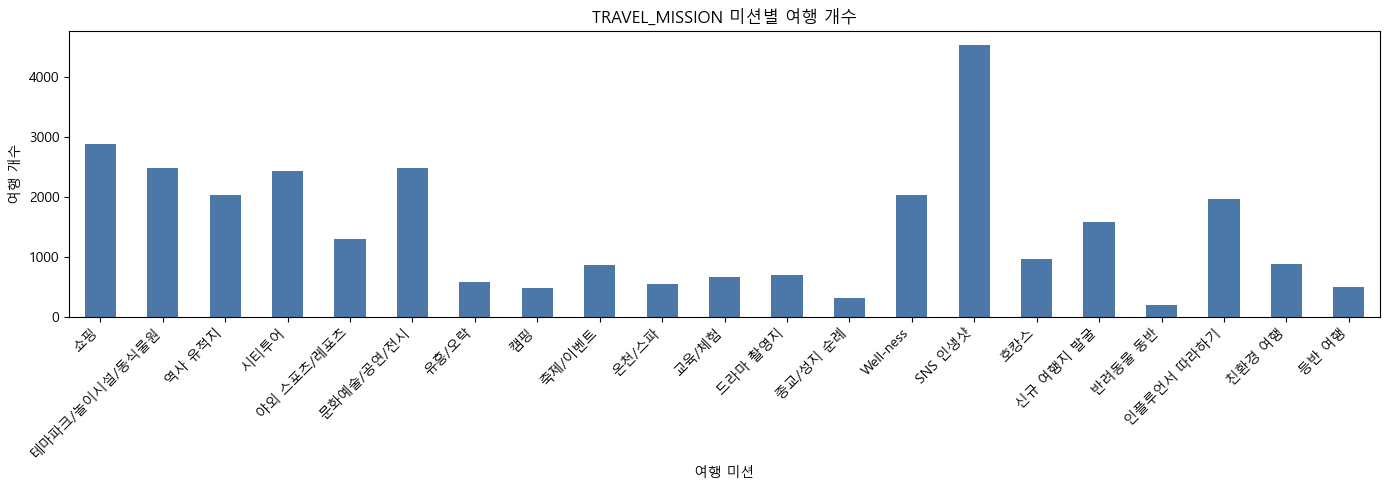

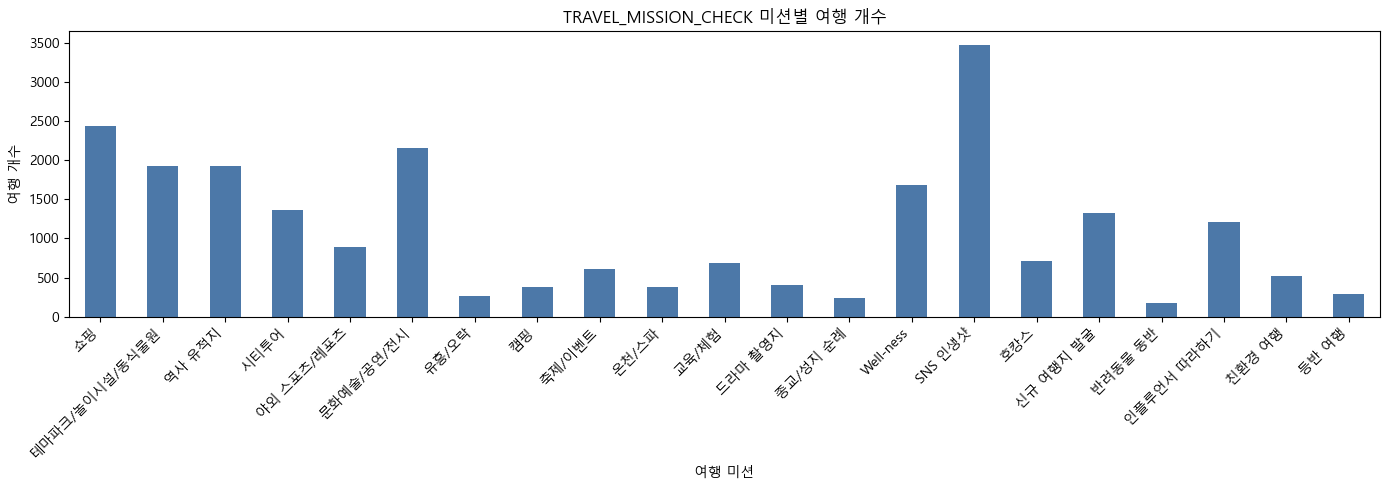

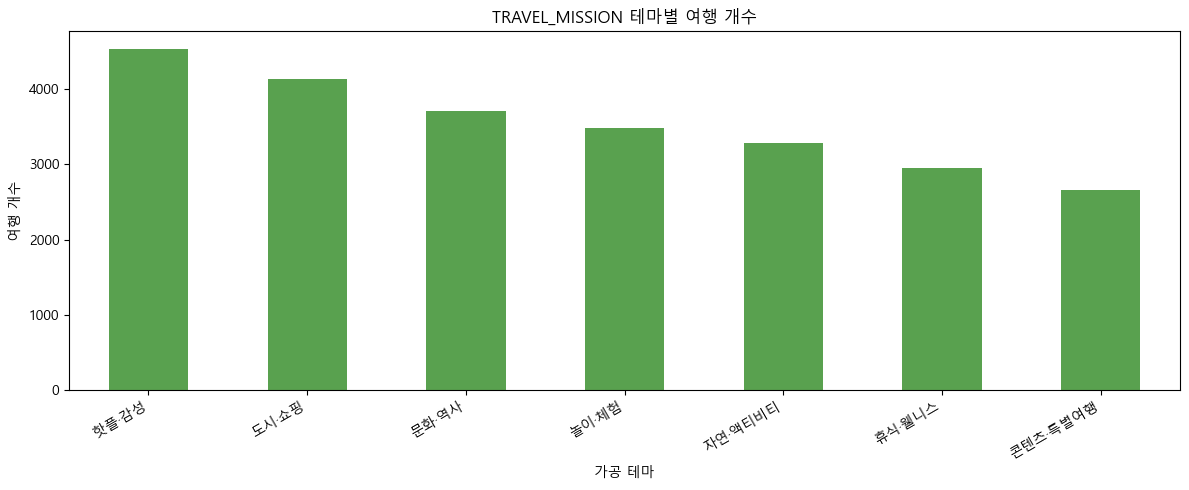

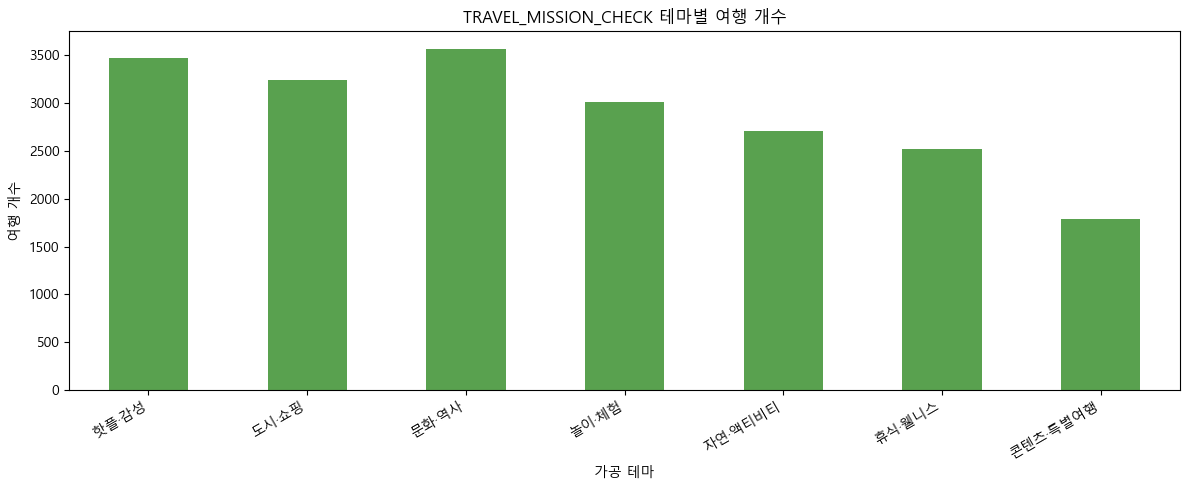

In [90]:
travel_mission_long = make_mission_long(travel_total_df, "TRAVEL_MISSION")
travel_mission_check_long = make_mission_long(travel_total_df, "TRAVEL_MISSION_CHECK")

travel_mission_counts = plot_mission_code_distribution(
    travel_mission_long,
    "TRAVEL_MISSION 미션별 여행 개수",
    "travel_mission_distribution.png",
)
travel_mission_check_counts = plot_mission_code_distribution(
    travel_mission_check_long,
    "TRAVEL_MISSION_CHECK 미션별 여행 개수",
    "travel_mission_check_distribution.png",
)
travel_mission_theme_counts = plot_mission_theme_distribution(
    travel_mission_long,
    "TRAVEL_MISSION 테마별 여행 개수",
    "travel_mission_theme_distribution.png",
)
travel_mission_check_theme_counts = plot_mission_theme_distribution(
    travel_mission_check_long,
    "TRAVEL_MISSION_CHECK 테마별 여행 개수",
    "travel_mission_check_theme_distribution.png",
)

for filename in [
    "travel_mission_distribution.png",
    "travel_mission_check_distribution.png",
    "travel_mission_theme_distribution.png",
    "travel_mission_check_theme_distribution.png",
]:
    output_path = FIGURES_PATH / filename
    assert output_path.exists() and output_path.stat().st_size > 0, f"저장 실패: {output_path}"


### (3) 여행자

In [91]:
print_col_efg("tn_traveller_master_여행객_Master")

### ===EFG 공통 : tn_traveller_master_여행객_Master===

Index(['TRAVELER_ID', 'RESIDENCE_SGG_CD', 'GENDER', 'AGE_GRP', 'EDU_NM',
       'EDU_FNSH_SE', 'MARR_STTS', 'FAMILY_MEMB', 'JOB_NM', 'JOB_ETC',
       'INCOME', 'HOUSE_INCOME', 'TRAVEL_TERM', 'TRAVEL_NUM',
       'TRAVEL_LIKE_SIDO_1', 'TRAVEL_LIKE_SGG_1', 'TRAVEL_LIKE_SIDO_2',
       'TRAVEL_LIKE_SGG_2', 'TRAVEL_LIKE_SIDO_3', 'TRAVEL_LIKE_SGG_3',
       'TRAVEL_STYL_1', 'TRAVEL_STYL_2', 'TRAVEL_STYL_3', 'TRAVEL_STYL_4',
       'TRAVEL_STYL_5', 'TRAVEL_STYL_6', 'TRAVEL_STYL_7', 'TRAVEL_STYL_8',
       'TRAVEL_STATUS_RESIDENCE', 'TRAVEL_STATUS_DESTINATION',
       'TRAVEL_STATUS_ACCOMPANY', 'TRAVEL_STATUS_YMD', 'TRAVEL_MOTIVE_1',
       'TRAVEL_MOTIVE_2', 'TRAVEL_MOTIVE_3', 'TRAVEL_COMPANIONS_NUM'],
      dtype='object')


In [92]:
# 여행자 df 통합 
traveller_total_df = concat_efg("tn_traveller_master_여행객_Master")
display(Markdown("### 여행객"))
display(traveller_total_df.head())

### 여행객

,TRAVELER_ID,RESIDENCE_SGG_CD,GENDER,AGE_GRP,EDU_NM,EDU_FNSH_SE,MARR_STTS,FAMILY_MEMB,JOB_NM,JOB_ETC,...,TRAVEL_STYL_7,TRAVEL_STYL_8,TRAVEL_STATUS_RESIDENCE,TRAVEL_STATUS_DESTINATION,TRAVEL_STATUS_ACCOMPANY,TRAVEL_STATUS_YMD,TRAVEL_MOTIVE_1,TRAVEL_MOTIVE_2,TRAVEL_MOTIVE_3,TRAVEL_COMPANIONS_NUM
0,e004720,41,여,60,4,1.0,3,3,11,NaN,...,5,5,경기도,서울,2인 가족 여행,2023-07-16~2023-07-16,2,6.0,NaN,1
1,e000914,30,여,20,6,1.0,1,1,3,NaN,...,4,1,대전광역시,서울,나홀로 여행,2023-06-03~2023-06-03,1,7.0,10.0,0
2,e003564,41,여,30,7,1.0,2,4,2,NaN,...,1,7,경기도,경기,자녀 동반 여행,2023-06-24~2023-06-24,8,3.0,7.0,3
3,e000396,41,여,30,6,1.0,2,2,2,NaN,...,1,6,경기도,인천,2인 가족 여행,2023-05-20~2023-05-21,9,1.0,7.0,1
4,e001890,11,남,20,6,1.0,1,4,3,NaN,...,5,6,서울특별시,경기,2인 여행(가족 외),2023-06-04~2023-06-04,3,1.0,5.0,1


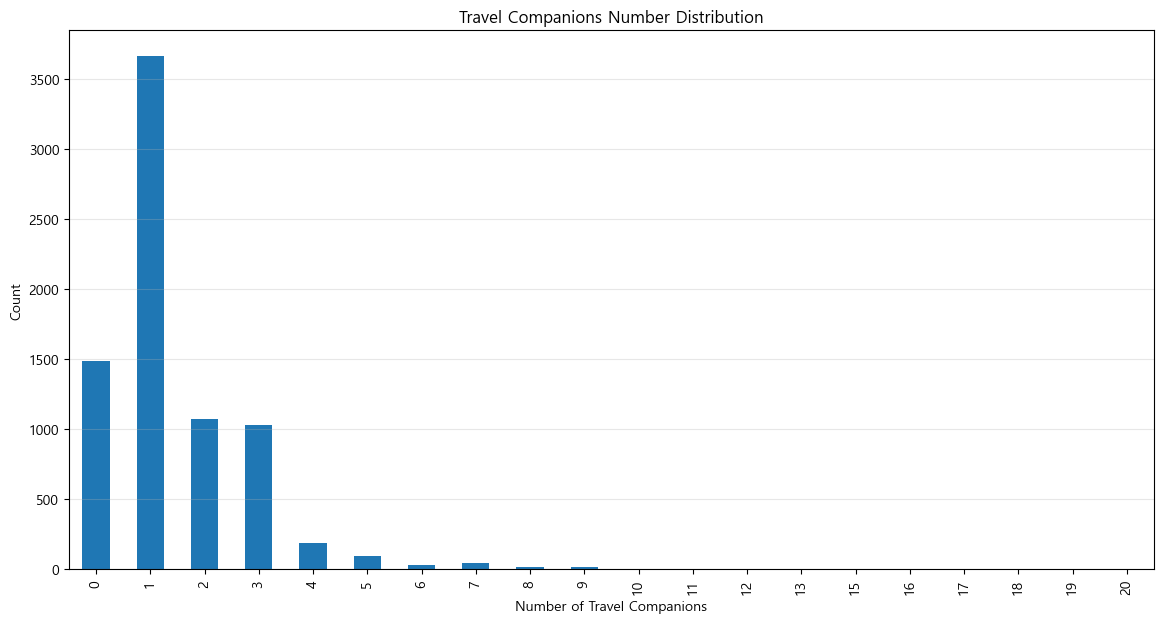

In [93]:
## 동반자 수 분포 저장
companion_counts = (
    traveller_total_df["TRAVEL_COMPANIONS_NUM"]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)
fig, ax = plt.subplots(figsize=(14, 7))
companion_counts.plot(kind="bar", ax=ax, color="#1f77b4")
ax.set_title("Travel Companions Number Distribution")
ax.set_xlabel("Number of Travel Companions")
ax.set_ylabel("Count")
ax.grid(axis="y", alpha=0.3)
save_figure(fig, "travel_companions_num_distribution.png")
plt.show()

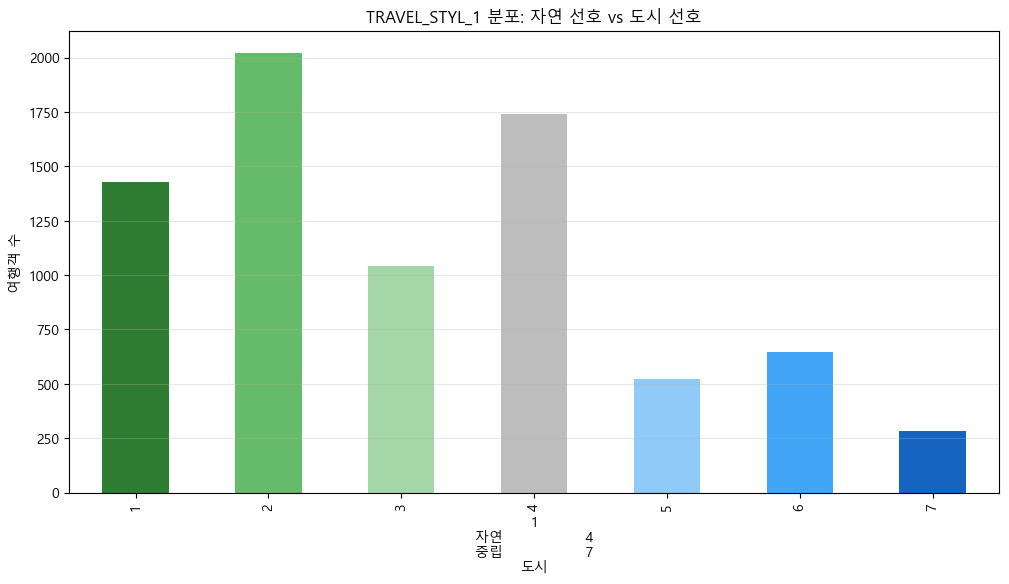

In [94]:
## TRAVEL_STYL_1 분포 저장
travel_styl_1_counts = (
    traveller_total_df["TRAVEL_STYL_1"]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)
fig, ax = plt.subplots(figsize=(12, 6))
travel_styl_1_counts.plot(
    kind="bar",
    ax=ax,
    color=["#2E7D32", "#66BB6A", "#A5D6A7", "#BDBDBD", "#90CAF9", "#42A5F5", "#1565C0"],
)
ax.set_title("TRAVEL_STYL_1 분포: 자연 선호 vs 도시 선호")
ax.set_xlabel("1\n자연                 4\n중립                 7\n도시")
ax.set_ylabel("여행객 수")
ax.grid(axis="y", alpha=0.3)
save_figure(fig, "travel_styl_1_distribution.png")
plt.show()

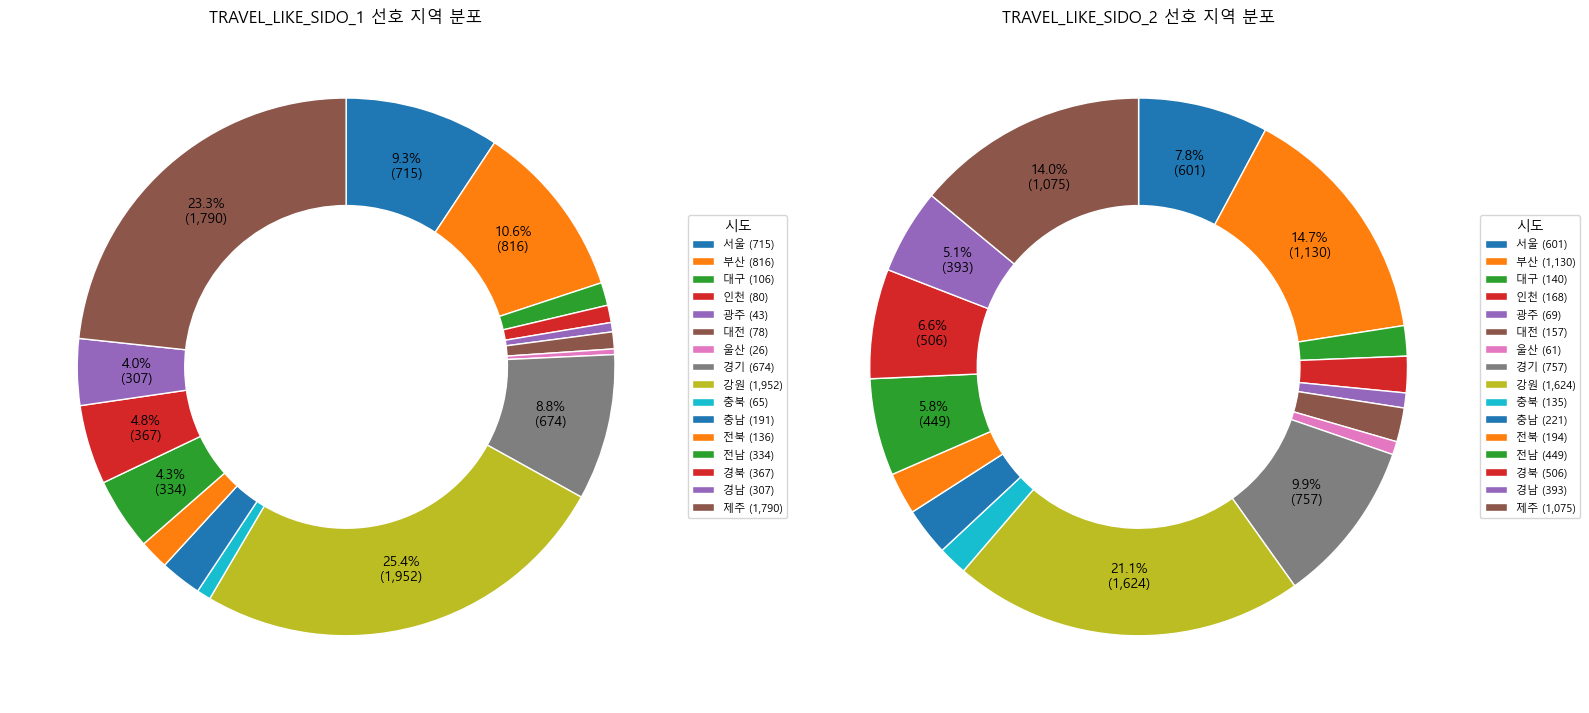

In [101]:
# TODO : TRAVEL_LIKE_SIDO_1 도넛 그래프와 TRAVEL_LIKE_SIDO_2 도넛 그래프 병렬 출력
sido_name_map = {
    11: "서울",
    26: "부산",
    27: "대구",
    28: "인천",
    29: "광주",
    30: "대전",
    31: "울산",
    36: "세종",
    41: "경기",
    42: "강원",
    43: "충북",
    44: "충남",
    45: "전북",
    46: "전남",
    47: "경북",
    48: "경남",
    50: "제주",
}


def count_sido(series):
    counts = series.dropna().astype(int).value_counts().sort_index()
    counts.index = [sido_name_map.get(code, str(code)) for code in counts.index]
    return counts


def autopct_over_threshold(values, threshold=3):
    total = values.sum()

    def formatter(pct):
        count = int(round(pct * total / 100))
        return f"{pct:.1f}%\n({count:,})" if pct >= threshold else ""

    return formatter


travel_like_sido_1_counts = count_sido(traveller_total_df["TRAVEL_LIKE_SIDO_1"])
travel_like_sido_2_counts = count_sido(traveller_total_df["TRAVEL_LIKE_SIDO_2"])

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, counts, title in [
    (axes[0], travel_like_sido_1_counts, "TRAVEL_LIKE_SIDO_1 선호 지역 분포"),
    (axes[1], travel_like_sido_2_counts, "TRAVEL_LIKE_SIDO_2 선호 지역 분포"),
]:
    wedges, _, _ = ax.pie(
        counts,
        startangle=90,
        counterclock=False,
        wedgeprops={"width": 0.4, "edgecolor": "white"},
        autopct=autopct_over_threshold(counts),
        pctdistance=0.78,
    )
    ax.set_title(title)
    ax.legend(
        wedges,
        [f"{label} ({count:,})" for label, count in counts.items()],
        title="시도",
        loc="center left",
        bbox_to_anchor=(1.0, 0.5),
        fontsize=8,
    )

plt.tight_layout()
save_figure(fig, "travel_like_sido_donut_distribution.png")
plt.show()


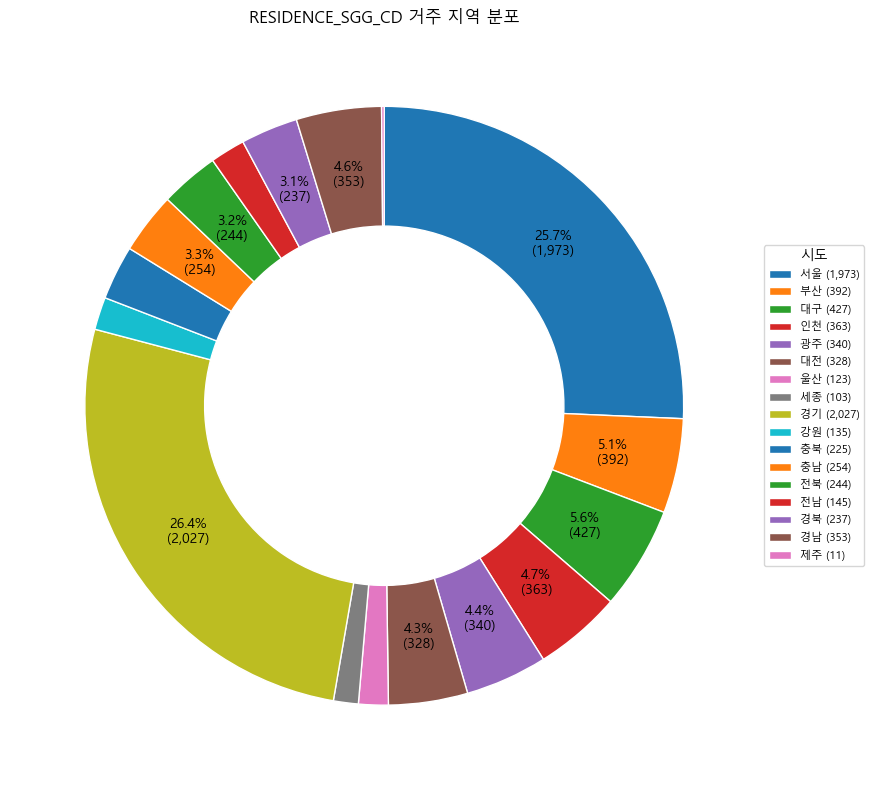

In [102]:
# TODO : RESIDENCE_SGG_CD 도넛 그래프 출력
residence_sgg_counts = count_sido(traveller_total_df["RESIDENCE_SGG_CD"])

fig, ax = plt.subplots(figsize=(10, 8))
wedges, _, _ = ax.pie(
    residence_sgg_counts,
    startangle=90,
    counterclock=False,
    wedgeprops={"width": 0.4, "edgecolor": "white"},
    autopct=autopct_over_threshold(residence_sgg_counts),
    pctdistance=0.78,
)
ax.set_title("RESIDENCE_SGG_CD 거주 지역 분포")
ax.legend(
    wedges,
    [f"{label} ({count:,})" for label, count in residence_sgg_counts.items()],
    title="시도",
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
    fontsize=8,
)

plt.tight_layout()
save_figure(fig, "residence_sgg_cd_donut_distribution.png")
plt.show()


In [103]:
# TODO : RESIDENCE_SGG_CD, TRAVEL_LIKE_SIDO_1 or TRAVEL_LIKE_SGG_1 unique한 값 출력
unique_columns = [
    "RESIDENCE_SGG_CD",
    "TRAVEL_LIKE_SIDO_1",
    "TRAVEL_LIKE_SGG_1",
]

for column in unique_columns:
    unique_values = sorted(traveller_total_df[column].dropna().astype(int).unique().tolist())
    print(f"{column} unique 개수: {len(unique_values)}")
    print(unique_values)


RESIDENCE_SGG_CD unique 개수: 17
[11, 26, 27, 28, 29, 30, 31, 36, 41, 42, 43, 44, 45, 46, 47, 48, 50]
TRAVEL_LIKE_SIDO_1 unique 개수: 16
[11, 26, 27, 28, 29, 30, 31, 41, 42, 43, 44, 45, 46, 47, 48, 50]
TRAVEL_LIKE_SGG_1 unique 개수: 215
[11110, 11140, 11170, 11200, 11215, 11230, 11260, 11290, 11305, 11320, 11350, 11380, 11410, 11440, 11470, 11500, 11530, 11545, 11560, 11590, 11620, 11650, 11680, 11710, 11740, 26110, 26140, 26170, 26200, 26230, 26260, 26290, 26320, 26350, 26380, 26410, 26440, 26500, 26530, 26710, 27110, 27140, 27170, 27200, 27230, 27260, 27290, 27710, 28110, 28140, 28177, 28185, 28200, 28237, 28245, 28260, 28710, 28720, 29110, 29140, 29155, 29170, 29200, 30110, 30140, 30170, 30200, 30230, 31110, 31140, 31170, 31200, 31710, 41110, 41130, 41150, 41170, 41190, 41210, 41220, 41250, 41270, 41280, 41290, 41310, 41360, 41370, 41390, 41410, 41430, 41450, 41460, 41480, 41500, 41550, 41570, 41590, 41610, 41630, 41650, 41670, 41800, 41820, 41830, 42110, 42130, 42150, 42170, 42190, 42210